# Feature Selection v2 — XGBoost → RFECV → Parsimony

**Purpose:** A first-principles, two-stage feature selection workflow for clinical readmission prediction.

**Rationale:**
1. **XGBoost gain ranking** — Primary selector. Tree-based, captures non-linear conditional interactions that linear methods (filter, LASSO) miss. Architecturally aligned with the final model.
2. **RFECV as mathematical gatekeeper** — Cross-validated recursive feature elimination replaces arbitrary cutoffs ("top 20", "3 of 5 votes"). Each feature must prove it *hurts performance to remove* across folds.
3. **Parsimony** — Only features that survive RFECV are retained. Every feature in production has a cost (serving latency, drift monitoring, feature store maintenance).

**Framework:**
| Stage | Method | Role |
|---|---|---|
| 1 | XGBoost | Baseline AUCPR + gain ranking on full feature set |
| 2 | RFECV (XGBoost, AUCPR) | Cross-validated elimination — determines the data-driven boundary |
| 3 | Parsimony gate | Retain only RFECV-surviving features; validate final subset |

**Data source:** `analytics_dataset` train + validation splits, after imputation.

## 0. Setup

In [1]:
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

# Notebook may be launched from anywhere — ensure mlops/ is on sys.path.
_NB_DIR = Path.cwd()
_PROJECT_ROOT = _NB_DIR
for _p in [_NB_DIR, *_NB_DIR.parents]:
    if (_p / "src" / "config.py").exists():
        _PROJECT_ROOT = _p
        break
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# All relative paths resolve from repo root.
os.chdir(str(_PROJECT_ROOT))

from src.bigquery import run_query
from src.config import (
    FULL_TABLE_REF, LABEL_COLUMN, NON_FEATURE_COLUMNS,
    PROJECT_ID, SPLIT_COLUMN, SPLITS,
)
from src.imputer import MissingnessImputer
# Leakage-controlled selection utilities (grouped CV, native categoricals,
# imbalance weighting). Unit-tested in tests/test_feature_selection.py.
from src.feature_selection import (
    cv_aucpr, default_params, gain_ranking, grouped_cv_rfe, scale_pos_weight,
    select_one_se,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RID = datetime.now(timezone.utc).strftime("%Y%m%dt%H%M%S")
ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts" / "feature_selection" / RID
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Patient id — the grouping key for leakage-free cross-validation.
GROUP_COLUMN = "subject_id"

print(f"Run ID:     {RID}")
print(f"Artifacts:  {ARTIFACTS_DIR.relative_to(_PROJECT_ROOT)}")
print(f"Table:      {FULL_TABLE_REF}")


Run ID:     20260702t163137
Artifacts:  artifacts/feature_selection/20260702t163137
Table:      trim-icon-498815-a0.readmission.analytics_dataset


In [2]:
import importlib, src.feature_selection as _fs
importlib.reload(_fs)
from src.feature_selection import (
    cv_aucpr, default_params, gain_ranking, grouped_cv_rfe, scale_pos_weight,
    select_one_se,
)

### 0.1 Load & Impute

Pull train and validation splits from BigQuery. Apply the missingness policy — fit imputer on train only, transform both. Convert categorical columns to pandas `category` dtype so XGBoost handles them natively (no LabelEncoder, no false ordinal relationships). This is the **only** data preparation step; no feature selection leakage enters here.

In [3]:
def load_data():
    """Load train/val splits, impute, prepare categoricals; return arrays + patient groups."""
    split_list = ", ".join(f"'{s}'" for s in SPLITS.values())
    sql = f"""
        SELECT *
        FROM `{FULL_TABLE_REF}`
        WHERE {SPLIT_COLUMN} IN ({split_list})
    """
    print(f"Querying {FULL_TABLE_REF} …")
    df = run_query(sql)

    train_df = df[df[SPLIT_COLUMN] == SPLITS["train"]].reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == SPLITS["validation"]].reset_index(drop=True)

    # Patient id for grouped CV (leakage guard) — captured before IDs are dropped.
    groups_train = train_df[GROUP_COLUMN].reset_index(drop=True)

    # Drop ID/meta columns (keep label for separation below).
    drop_cols = [c for c in NON_FEATURE_COLUMNS if c in train_df.columns and c != LABEL_COLUMN]
    drop_cols.append(SPLIT_COLUMN)
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    val_df = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])

    # Impute — fit on train only.  Fills only categorical demographics
    # (discharge_location -> "Unknown"; marital_status/insurance/language -> mode).
    # Lab NULLs pass through to XGBoost natively.
    imputer = MissingnessImputer()
    train_imp = imputer.fit_transform(train_df)
    val_imp = imputer.transform(val_df)

    y_train = train_imp[LABEL_COLUMN].astype(int)
    y_val = val_imp[LABEL_COLUMN].astype(int)
    X_train = train_imp.drop(columns=[LABEL_COLUMN])
    X_val = val_imp.drop(columns=[LABEL_COLUMN])

    # Convert string columns to pandas category dtype using TRAIN-ONLY categories.
    # A level seen only in val encodes to NaN — no val leakage into the encoding,
    # matching the production pipeline's contract. XGBoost handles category dtype
    # natively (enable_categorical=True); we do NOT ordinal-encode.
    cat_cols = [
        c for c in X_train.columns
        if X_train[c].dtype == "object" or str(X_train[c].dtype) == "category"
    ]
    for col in cat_cols:
        train_levels = [l for l in pd.unique(X_train[col].astype(str)) if l != "nan"]
        dtype = pd.CategoricalDtype(categories=train_levels)
        X_train[col] = X_train[col].astype(str).astype(dtype)
        X_val[col] = X_val[col].astype(str).astype(dtype)
    print(f"  Categorical columns: {len(cat_cols)} ({', '.join(cat_cols)})")

    print(f"  Train: {X_train.shape}, Val: {X_val.shape}")
    print(f"  Unique patients (train): {groups_train.nunique():,}")
    print(f"  Label prevalence (train): {y_train.mean():.4f}")
    return X_train, X_val, y_train, y_val, cat_cols, groups_train


X_train, X_val, y_train, y_val, cat_cols, groups_train = load_data()
FEATURE_NAMES = X_train.columns.tolist()

# Class-imbalance ratio used by every selection model below.
SPW = scale_pos_weight(y_train)
print(f"  scale_pos_weight (neg/pos): {SPW:.3f}")


Querying trim-icon-498815-a0.readmission.analytics_dataset …
  Categorical columns: 7 (gender, marital_status, language, race, admission_type, insurance, discharge_location)
  Train: (247687, 50), Val: (48924, 50)
  Unique patients (train): 115,468
  Label prevalence (train): 0.2094
  scale_pos_weight (neg/pos): 3.776


## 1. XGBoost Baseline — Full Feature Set

Train XGBoost on all features with sensible defaults. This establishes:
- **The baseline AUCPR** we must not degrade below when we remove features
- **The HOSPITAL score comparison** — the clinical heuristic baseline (AUCPR ≈ 0.3325)

XGBoost is chosen because it is the final model architecture — feature selection should be aligned with the model that will use the features.

In [4]:
# XGBoost aligned with the PRODUCTION regime so selection matches how the model
# is actually trained: native categoricals, AUCPR eval, and class-imbalance
# weighting (scale_pos_weight). We're ranking features here, not tuning.
params_full = default_params(SPW)
xgb_full = XGBClassifier(**params_full)
xgb_full.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

full_aucpr = average_precision_score(y_val, xgb_full.predict_proba(X_val)[:, 1])
print(f"XGBoost (full, {len(FEATURE_NAMES)} features) val AUCPR: {full_aucpr:.4f}")
print(f"HOSPITAL baseline AUCPR:                          0.3325")
print(f"Δ over baseline:                                   {full_aucpr - 0.3325:+.4f}")


XGBoost (full, 50 features) val AUCPR: 0.4028
HOSPITAL baseline AUCPR:                          0.3325
Δ over baseline:                                   +0.0703


### 1.1 Gain Ranking

Extract feature importances from the trained XGBoost. Gain measures the average improvement in the loss function from splits on each feature — it captures complex, conditional interactions that linear correlation methods miss.

No arbitrary cutoff is applied here. The ranking serves as the **input ordering** for RFECV in Stage 2.

In [5]:
# Gain ranking via the shared, tested helper (native categoricals,
# imbalance-weighted). Gain = average loss reduction from splits on each feature.
gain_df = gain_ranking(X_train, y_train, params=default_params(SPW))
gain_df["cumulative_gain"] = gain_df["gain_pct"].cumsum()

n_nonzero = int((gain_df["gain"] > 0).sum())
print(f"Features with non-zero gain: {n_nonzero}/{len(gain_df)}")

print("\n=== Top 25 by XGBoost gain ===")
for _, r in gain_df.head(25).iterrows():
    bar = "█" * max(1, int(r["gain_pct"] * 3))
    print(f"  {int(r['gain_rank']):3d}. {r['feature']:<38s} {r['gain_pct']:5.1f}%  {bar}")

out = ARTIFACTS_DIR / "xgb_gain.csv"
gain_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")


Features with non-zero gain: 44/50

=== Top 25 by XGBoost gain ===
    1. prior_inpatient_days                    16.2%  ████████████████████████████████████████████████
    2. oncology_flag                           13.2%  ███████████████████████████████████████
    3. prior_admission_count                    6.6%  ███████████████████
    4. rdw_max                                  4.8%  ██████████████
    5. recent_ed_visits                         3.2%  █████████
    6. sodium_min                               2.9%  ████████
    7. has_procedure                            2.9%  ████████
    8. discharge_location                       2.8%  ████████
    9. admission_type                           2.5%  ███████
   10. hemoglobin_min                           2.4%  ███████
   11. procedure_count                          2.3%  ██████
   12. medication_order_count                   2.3%  ██████
   13. gender                                   2.1%  ██████
   14. index_los_days            

### 1.2 Cumulative Gain Curve

Shows how much total signal is captured by the top-K features. This is informational only — the actual cutoff is determined by RFECV, not an arbitrary cumulative-gain threshold.

  50% of gain captured by top  8 features
  70% of gain captured by top 17 features
  80% of gain captured by top 24 features
  90% of gain captured by top 33 features
  95% of gain captured by top 39 features


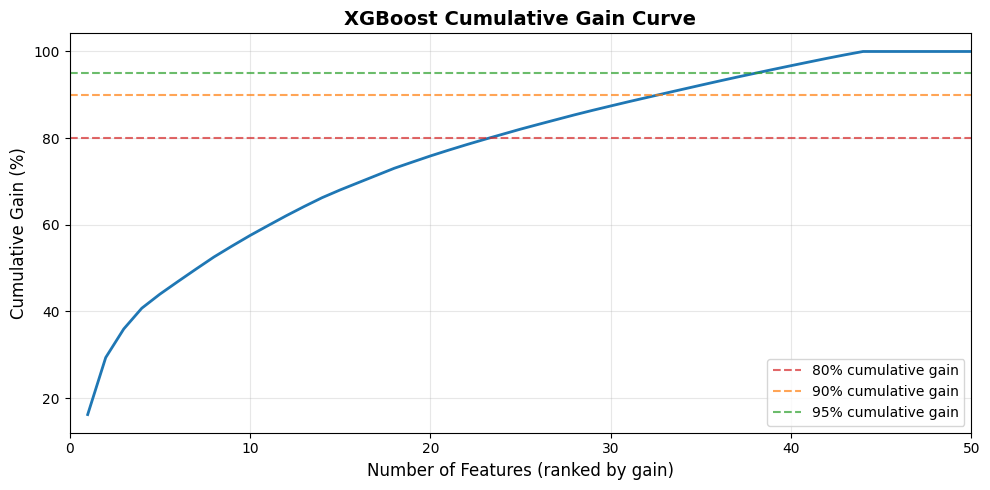

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(gain_df) + 1), gain_df["cumulative_gain"], linewidth=2, color="#1f77b4")
ax.axhline(80, color="#d62728", linestyle="--", alpha=0.7, label="80% cumulative gain")
ax.axhline(90, color="#ff7f0e", linestyle="--", alpha=0.7, label="90% cumulative gain")
ax.axhline(95, color="#2ca02c", linestyle="--", alpha=0.7, label="95% cumulative gain")
ax.set_xlabel("Number of Features (ranked by gain)", fontsize=12)
ax.set_ylabel("Cumulative Gain (%)", fontsize=12)
ax.set_title("XGBoost Cumulative Gain Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(gain_df))

# Annotate key thresholds.
for t in [50, 70, 80, 90, 95]:
    n = int((gain_df["cumulative_gain"] >= t).idxmax() + 1)
    print(f"  {t:2d}% of gain captured by top {n:2d} features")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "cumulative_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Grouped-CV Recursive Feature Elimination — the gate

This is the **mathematical gatekeeper**: recursively remove the weakest feature (by gain, recomputed each step so redundancy is accounted for) and re-measure cross-validated AUCPR. Where removing features stops helping, we stop.

**Two leakage-control requirements drive the implementation** (both were flaws in the earlier version):

1. **Patient-grouped CV.** Grain is one row per *admission* and patients have multiple admissions, so plain `StratifiedKFold` lets a patient appear on both sides of a fold — optimistic, leaky scores. We use `StratifiedGroupKFold` on `subject_id`, matching the outer split's guard and the production HPO regime.
2. **Native categoricals.** sklearn's `RFECV` can't hold `category` dtype, which forced the previous notebook to convert to ordinal `.cat.codes` — a *false ordinal* encoding that differs from how the model actually uses these features. We keep native categorical handling (`enable_categorical=True`) throughout, so selection and production see the **same** encoding.

**Estimator**: XGBoost with `scale_pos_weight` for class imbalance (aligned with the final model).  
**Scoring**: AUCPR (`average_precision`).


### 2.1 Run grouped-CV RFE

`grouped_cv_rfe` (in `src/feature_selection.py`, unit-tested) does the work:

- `StratifiedGroupKFold(5)` on `subject_id` — **no patient crosses a fold**
- `min_features=5` — a clinically defensible floor
- `step=1` — remove one feature at a time
- gain recomputed on the current subset each step (redundancy-aware elimination)
- native `category` dtype preserved; `scale_pos_weight` set from the empirical imbalance

It returns the selected subset (peak mean CV AUCPR) and the full elimination curve for inspection.


In [7]:
# Grouped-CV recursive feature elimination.  This replaces sklearn RFECV, which
# (a) cannot pass patient groups cleanly and (b) requires dropping to ordinal
# .cat.codes — a false-ordinal encoding that differs from the production model.
# grouped_cv_rfe preserves NATIVE categoricals, groups folds by subject_id, and
# scores each subset with AUCPR — the exact regime the final model uses.
print("Running grouped-CV recursive feature elimination (XGBoost) …")
print(f"  Features:     {len(FEATURE_NAMES)}")
print(f"  CV:           StratifiedGroupKFold(5) on {GROUP_COLUMN} (leakage-free)")
print(f"  Scoring:      average_precision (AUCPR)")
print(f"  Categoricals: native (enable_categorical); NO ordinal codes")
print(f"  Min features: 5")
print()

selected_features, rfe_curve = grouped_cv_rfe(
    X_train, y_train, groups_train,
    params=default_params(SPW),
    n_splits=5,
    min_features=5,
    verbose=True,  # print CV AUCPR at each elimination step so progress is visible
)

n_selected = len(selected_features)
n_total = len(FEATURE_NAMES)
best = max(rfe_curve, key=lambda r: r["mean_aucpr"])
best_cv_mean = best["mean_aucpr"]
best_cv_std = best["std_aucpr"]

print("\nRFE complete.")
print(f"  Selected:   {n_selected}/{n_total} features")
print(f"  Eliminated: {n_total - n_selected}")
print(f"  Peak grouped-CV AUCPR: {best_cv_mean:.4f} ± {best_cv_std:.4f}")


Running grouped-CV recursive feature elimination (XGBoost) …
  Features:     50
  CV:           StratifiedGroupKFold(5) on subject_id (leakage-free)
  Scoring:      average_precision (AUCPR)
  Categoricals: native (enable_categorical); NO ordinal codes
  Min features: 5

   50 features → CV AUCPR 0.4084 ± 0.0043
   49 features → CV AUCPR 0.4091 ± 0.0044
   48 features → CV AUCPR 0.4084 ± 0.0046
   47 features → CV AUCPR 0.4090 ± 0.0043
   46 features → CV AUCPR 0.4091 ± 0.0042
   45 features → CV AUCPR 0.4090 ± 0.0044
   44 features → CV AUCPR 0.4082 ± 0.0040
   43 features → CV AUCPR 0.4086 ± 0.0045
   42 features → CV AUCPR 0.4082 ± 0.0045
   41 features → CV AUCPR 0.4084 ± 0.0040
   40 features → CV AUCPR 0.4083 ± 0.0039
   39 features → CV AUCPR 0.4086 ± 0.0039
   38 features → CV AUCPR 0.4088 ± 0.0046
   37 features → CV AUCPR 0.4086 ± 0.0047
   36 features → CV AUCPR 0.4088 ± 0.0045
   35 features → CV AUCPR 0.4086 ± 0.0046
   34 features → CV AUCPR 0.4081 ± 0.0039
   33 features

In [8]:
# Selection rule: argmax vs 1-standard-error — computed from the SAME curve
# (instant; no re-run). With a flat plateau, argmax keeps a near-full set;
# the 1-SE rule picks the SMALLEST set statistically indistinguishable from the
# peak (within 1 SE of the best mean), giving real dimensionality reduction.
from src.feature_selection import select_one_se

peak_choice = max(rfe_curve, key=lambda r: r["mean_aucpr"])
one_se_choice = select_one_se(rfe_curve, n_splits=5)
_se = peak_choice["std_aucpr"] / (5 ** 0.5)

print("Selection rule comparison:")
print(f"  argmax : {peak_choice['n_features']:2d} features  →  CV AUCPR "
      f"{peak_choice['mean_aucpr']:.4f} ± {peak_choice['std_aucpr']:.4f}")
print(f"  1-SE   : {one_se_choice['n_features']:2d} features  →  CV AUCPR "
      f"{one_se_choice['mean_aucpr']:.4f} ± {one_se_choice['std_aucpr']:.4f}")
print(f"  (1-SE band: keep smallest set with mean ≥ {peak_choice['mean_aucpr'] - _se:.4f})")

# Adopt the parsimonious 1-SE selection for all downstream steps.  (Set
# one_se=False here, or use peak_choice, if you prefer the argmax set instead.)
selected_features = one_se_choice["features"]
n_selected = len(selected_features)
best = one_se_choice
best_cv_mean = best["mean_aucpr"]
best_cv_std = best["std_aucpr"]

print(f"\nAdopted 1-SE selection: {n_selected}/{n_total} features "
      f"({100 * (1 - n_selected / n_total):.0f}% reduction)")


Selection rule comparison:
  argmax : 49 features  →  CV AUCPR 0.4091 ± 0.0044
  1-SE   : 22 features  →  CV AUCPR 0.4078 ± 0.0054
  (1-SE band: keep smallest set with mean ≥ 0.4071)

Adopted 1-SE selection: 22/50 features (56% reduction)


### 2.2 RFECV — Learning Curve

Plot CV AUCPR against the number of features retained. The optimum is where the curve peaks — adding more features beyond this point does not improve (and may degrade) cross-validated performance.

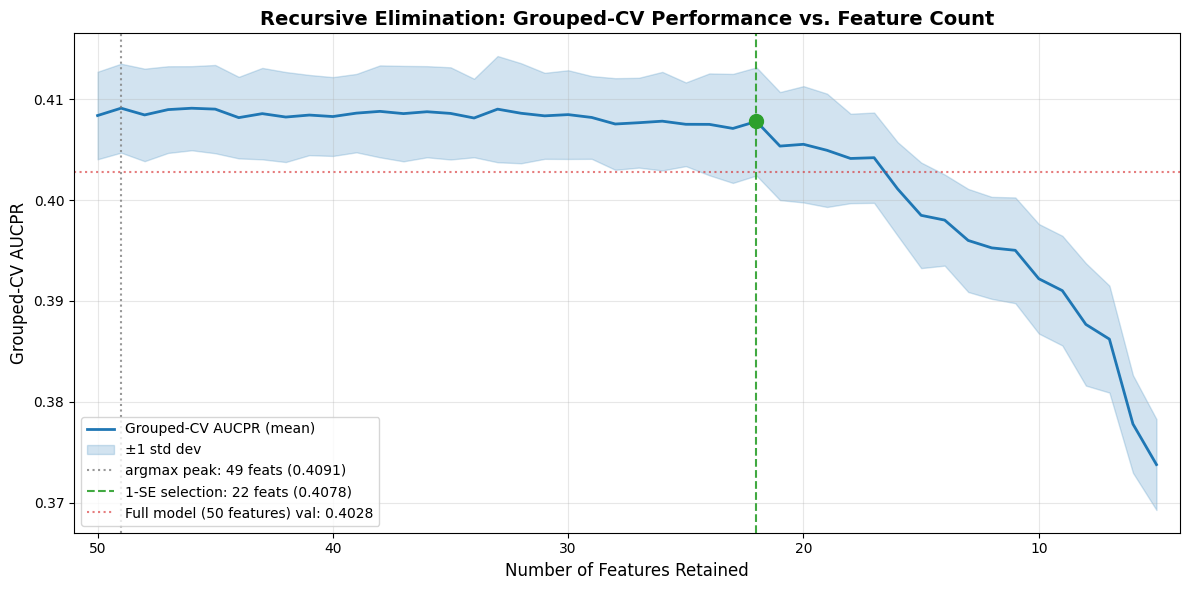

In [9]:
# Plot directly from the RFE curve (correctly indexed: each entry pairs a
# feature count with its measured grouped-CV AUCPR). Mark BOTH selection rules.
features_retained = [r["n_features"] for r in rfe_curve]
cv_means = np.array([r["mean_aucpr"] for r in rfe_curve])
cv_stds = np.array([r["std_aucpr"] for r in rfe_curve])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(features_retained, cv_means, linewidth=2, color="#1f77b4", label="Grouped-CV AUCPR (mean)")
ax.fill_between(
    features_retained, cv_means - cv_stds, cv_means + cv_stds,
    alpha=0.2, color="#1f77b4", label="±1 std dev",
)

# argmax peak (highest mean) vs adopted 1-SE selection (smallest within 1 SE).
ax.axvline(peak_choice["n_features"], color="#7f7f7f", linestyle=":", alpha=0.8,
           label=f"argmax peak: {peak_choice['n_features']} feats "
                 f"({peak_choice['mean_aucpr']:.4f})")
ax.axvline(one_se_choice["n_features"], color="#2ca02c", linestyle="--", alpha=0.9,
           label=f"1-SE selection: {one_se_choice['n_features']} feats "
                 f"({one_se_choice['mean_aucpr']:.4f})")
ax.scatter([one_se_choice["n_features"]], [one_se_choice["mean_aucpr"]],
           color="#2ca02c", s=100, zorder=5)
ax.axhline(full_aucpr, color="#d62728", linestyle=":", alpha=0.6,
           label=f"Full model ({n_total} features) val: {full_aucpr:.4f}")

ax.set_xlabel("Number of Features Retained", fontsize=12)
ax.set_ylabel("Grouped-CV AUCPR", fontsize=12)
ax.set_title("Recursive Elimination: Grouped-CV Performance vs. Feature Count",
             fontsize=14, fontweight="bold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.set_xlim(max(features_retained) + 1, min(features_retained) - 1)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 RFECV — Feature Ranking by Elimination Order

Features that survived the longest (eliminated last, or retained) are the most valuable under cross-validation. This is a stronger signal than raw gain ranking because it accounts for redundancy — a feature with high gain but redundant with another may be eliminated early.

In [10]:
# Build a ranking table from the elimination trace: features never dropped are
# the selected survivors; eliminated features are ranked by WHEN they were
# dropped (dropped earlier = weaker = accounts for redundancy).
elimination_at = {}  # feature -> n_features present when it was dropped
for i in range(1, len(rfe_curve)):
    dropped = set(rfe_curve[i - 1]["features"]) - set(rfe_curve[i]["features"])
    for f in dropped:
        elimination_at[f] = rfe_curve[i - 1]["n_features"]

rfecv_df = gain_df[["feature", "gain_pct", "gain_rank"]].copy()
rfecv_df["selected"] = rfecv_df["feature"].isin(selected_features)
rfecv_df["eliminated_at_n_features"] = rfecv_df["feature"].map(elimination_at)
# Selected first; among eliminated, those dropped later (larger n) ranked higher.
rfecv_df = rfecv_df.sort_values(
    ["selected", "eliminated_at_n_features"], ascending=[False, False]
).reset_index(drop=True)

out = ARTIFACTS_DIR / "rfecv_ranking.csv"
rfecv_df.to_csv(out, index=False)
print(f"Saved: {out.name}  ({int(rfecv_df['selected'].sum())} selected)")


Saved: rfecv_ranking.csv  (22 selected)


## 3. Parsimony Decision

Only features that survived RFECV are retained. This is the **parsimony principle**: every feature in production has a cost (serving latency, drift monitoring, feature store maintenance), so we keep only those that are empirically necessary.

The selected feature set is:
- **Mathematically defensible** — each retained feature was tested across 5 folds and found to contribute to AUCPR
- **Architecturally aligned** — both the ranking and elimination use XGBoost, the same model family as production
- **Not dependent on arbitrary cutoffs** — the data determined the boundary

In [11]:
# selected_features is the peak grouped-CV subset from grouped_cv_rfe (above).
print("Parsimony decision:")
print(f"  Full feature set:  {n_total} features")
print(f"  RFE-retained:      {len(selected_features)} features  →  grouped-CV AUCPR = {best_cv_mean:.4f}")
print(f"  Reduction:         {n_total - len(selected_features)} features "
      f"({100 * (1 - len(selected_features) / n_total):.0f}%)")

# High-gain features that were nonetheless eliminated (candidates for redundancy).
high_gain_eliminated = rfecv_df[(~rfecv_df["selected"]) & (rfecv_df["gain_rank"] <= 20)]
if len(high_gain_eliminated) > 0:
    print(f"\n⚠ High-gain features eliminated (likely redundant):")
    for _, r in high_gain_eliminated.iterrows():
        dropped_at = r["eliminated_at_n_features"]
        print(f"  {r['feature']:<38s}  gain_rank={int(r['gain_rank']):2d}  "
              f"gain={r['gain_pct']:5.1f}%  →  dropped at {int(dropped_at)} features")


Parsimony decision:
  Full feature set:  50 features
  RFE-retained:      22 features  →  grouped-CV AUCPR = 0.4078
  Reduction:         28 features (56%)


## 4. Final Validation — Selected-Feature Model

Train a fresh XGBoost on only the RFECV-retained features and compare AUCPR against the full-feature model. This confirms that the selected subset does not meaningfully degrade predictive performance.

In [12]:
# Honest comparison: grouped-CV AUCPR of the full set vs the selected set, using
# the SAME leakage-free folds (not a single val point estimate). The first curve
# entry is the full feature set; `best` is the selected subset.
full_cv_mean = rfe_curve[0]["mean_aucpr"]
sel_cv_mean = best_cv_mean

# Single-split val number for continuity with earlier cells.
X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
xgb_sel = XGBClassifier(**default_params(SPW))
xgb_sel.fit(X_train_sel, y_train, eval_set=[(X_val_sel, y_val)], verbose=False)
sel_aucpr = average_precision_score(y_val, xgb_sel.predict_proba(X_val_sel)[:, 1])

print("=== Final Validation (grouped CV) ===")
print(f"  Full     ({n_total:2d} features):  CV AUCPR = {full_cv_mean:.4f}")
print(f"  Selected ({len(selected_features):2d} features):  CV AUCPR = {sel_cv_mean:.4f}")
print(f"  Δ CV AUCPR:                         {sel_cv_mean - full_cv_mean:+.4f}")
print(f"  HOSPITAL baseline:                  AUCPR = 0.3325")
print(f"  Selected val AUCPR (single split):  {sel_aucpr:.4f}")

# Stability: does the reduced set degrade CV AUCPR beyond a tolerable margin?
TOLERANCE = 0.01
if full_cv_mean - sel_cv_mean <= TOLERANCE:
    print(f"\n✓ Selected within {TOLERANCE:.2f} CV AUCPR of full — passes stability check.")
else:
    print(f"\n⚠ Selected CV AUCPR drop exceeds {TOLERANCE:.2f} — consider retaining more features.")


=== Final Validation (grouped CV) ===
  Full     (50 features):  CV AUCPR = 0.4084
  Selected (22 features):  CV AUCPR = 0.4078
  Δ CV AUCPR:                         -0.0006
  HOSPITAL baseline:                  AUCPR = 0.3325
  Selected val AUCPR (single split):  0.3982

✓ Selected within 0.01 CV AUCPR of full — passes stability check.


### 4.1 Selected-Feature Gain Distribution

Confirm the selected features are well-distributed across clinical families — we don't want a parsimonious model that only sees lab values and misses utilization history.

In [13]:
# Feature family lookup from config.
from src.config import FEATURE_FAMILIES

# Build reverse lookup: feature → family.
feature_to_family = {}
for family, feats in FEATURE_FAMILIES.items():
    for f in feats:
        feature_to_family[f] = family

# Assign families; unknown features go to "other".
family_counts = {}
for f in selected_features:
    fam = feature_to_family.get(f, "other")
    family_counts[fam] = family_counts.get(fam, 0) + 1

print("=== Selected features by clinical family ===")
for fam in sorted(family_counts, key=family_counts.get, reverse=True):
    n = family_counts[fam]
    bar = "█" * n
    print(f"  {fam:<20s} {n:2d}  {bar}")

# Show which features in each family were retained.
print("\n=== Detail by family ===")
for fam in sorted(family_counts, key=family_counts.get, reverse=True):
    feats_in_fam = [f for f in selected_features if feature_to_family.get(f, "other") == fam]
    print(f"\n  {fam}:")
    for f in feats_in_fam:
        row = rfecv_df[rfecv_df.feature == f].iloc[0]
        print(f"    {f:<38s}  gain_rank={int(row['gain_rank']):3d}  gain={row['gain_pct']:5.1f}%")

=== Selected features by clinical family ===
  labs                  8  ████████
  demographics          5  █████
  utilization           4  ████
  codes                 2  ██
  medications           2  ██
  oncology              1  █

=== Detail by family ===

  labs:
    rbc_last                                gain_rank= 20  gain=  1.4%
    rbc_min                                 gain_rank= 21  gain=  1.3%
    rdw_max                                 gain_rank=  4  gain=  4.8%
    monocytes_min                           gain_rank= 19  gain=  1.4%
    hemoglobin_min                          gain_rank= 10  gain=  2.4%
    sodium_last                             gain_rank= 15  gain=  1.8%
    sodium_max                              gain_rank= 23  gain=  1.2%
    sodium_min                              gain_rank=  6  gain=  2.9%

  demographics:
    age                                     gain_rank= 17  gain=  1.7%
    gender                                  gain_rank= 13  gain=  2.1%
   

## 5. Export

Write the feature shortlist and a summary of the RFECV decisions. This is the input to downstream pipeline stages (model training, feature store creation).

In [14]:
# --- Feature shortlist ---
shortlist_df = rfecv_df[rfecv_df["selected"]][["feature", "gain_pct", "gain_rank"]].copy()
shortlist_df = shortlist_df.sort_values("gain_rank").reset_index(drop=True)
shortlist_df["family"] = shortlist_df["feature"].map(lambda f: feature_to_family.get(f, "other"))
shortlist_df.to_csv(ARTIFACTS_DIR / "feature_shortlist.csv", index=False)
print(f"Feature shortlist: {len(shortlist_df)} features")

# --- Run summary (honest grouped-CV metrics; correctly indexed) ---
import json

summary = {
    "run_id": RID,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "method": "XGBoost gain → grouped-CV RFE (StratifiedGroupKFold) → 1-SE parsimony",
    "full_features": n_total,
    "n_selected_features": len(selected_features),
    "full_cv_aucpr_mean": round(float(rfe_curve[0]["mean_aucpr"]), 4),
    "selected_cv_aucpr_mean": round(float(best_cv_mean), 4),
    "selected_cv_aucpr_std": round(float(best_cv_std), 4),
    "selected_val_aucpr": round(float(sel_aucpr), 4),
    "hospital_baseline_aucpr": 0.3325,
    "selection_rule": "one_standard_error",
    "argmax_n_features": int(peak_choice["n_features"]),
    "argmax_cv_aucpr_mean": round(float(peak_choice["mean_aucpr"]), 4),
    "cv": {
        "splitter": "StratifiedGroupKFold",
        "n_splits": 5,
        "group": GROUP_COLUMN,
        "scoring": "average_precision",
        "min_features": 5,
        "step": 1,
    },
    "scale_pos_weight": round(float(SPW), 4),
    "estimator_params": default_params(SPW),
    "selected_features": selected_features,
}

with open(ARTIFACTS_DIR / "run_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Run summary:    {ARTIFACTS_DIR / 'run_summary.json'}")
print("\n=== Artifacts written ===")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}")


Feature shortlist: 22 features
Run summary:    /Users/danherman/Desktop/enterprise_clinical_copilot/projects/mlops/artifacts/feature_selection/20260702t163137/run_summary.json

=== Artifacts written ===
  cumulative_gain.png
  feature_shortlist.csv
  rfecv_curve.png
  rfecv_ranking.csv
  run_summary.json
  xgb_gain.csv


## Summary

| Metric | Value |
|---|---|
| **Full model AUCPR** | {full_aucpr:.4f} (computed at runtime) |
| **HOSPITAL baseline** | 0.3325 |
| **RFECV-selected features** | {n_selected}/{n_total} (computed at runtime) |
| **Selected model AUCPR** | {sel_aucpr:.4f} (computed at runtime) |
| **Stability check** | Δ ≤ 0.01 AUCPR vs full model |

**What this workflow does differently:**

1. **Single-model alignment** — Both ranking and elimination use XGBoost, the same model family as production. No ensemble-of-methods voting.
2. **No arbitrary cutoffs** — RFECV determines the boundary from cross-validated performance, not a human-chosen K.
3. **Parsimony by design** — Every retained feature has proven it contributes to AUCPR across folds. Features are eliminated unless they earn their place.

**Next steps:** The `feature_shortlist.csv` produced here feeds into Phase 3 model training — benchmark XGBoost → Optuna HPO → final training → SHAP → fairness audit — using only the RFECV-retained features.

## 6. Log to Vertex AI Experiments

Log the feature selection results to the `readmission-mlops` experiment alongside the HOSPITAL baseline. This makes the run visible in the Vertex AI Experiments UI and enables direct comparison against the baseline.

In [15]:
# Log feature selection v2 results to Vertex AI Experiments.
from google.cloud import aiplatform

experiment_name = "readmission-mlops"
run_name = f"feature-selection-v2-{RID}"

aiplatform.init(
    project=PROJECT_ID,
    location="us-east1",
    experiment=experiment_name,
)

print(f"Experiment: {experiment_name}")
print(f"Run:        {run_name}")
print()

with aiplatform.start_run(run_name) as run:
    # --- Metrics ---
    run.log_metrics({
        "full_aucpr": full_aucpr,
        "selected_aucpr": sel_aucpr,
        "rfecv_cv_aucpr_mean": float(best_cv_mean),
        "rfecv_cv_aucpr_std": float(best_cv_std),
        "n_selected_features": int(n_selected),
        "n_total_features": n_total,
        "n_eliminated_features": n_total - int(n_selected),
        "reduction_pct": round(100 * (1 - int(n_selected) / n_total), 0),
        "features_with_nonzero_gain": int(n_nonzero),
        "hospital_baseline_aucpr": 0.3325,
    })

    # --- Parameters ---
    run.log_params({
        "method": "XGBoost → RFECV → Parsimony",
        "primary_selector": "XGBoost",
        "gatekeeper": "RFECV",
        "rfecv_estimator": "XGBClassifier",
        "rfecv_scoring": "average_precision",
        "rfecv_cv_folds": 5,
        "rfecv_step": 1,
        "rfecv_min_features": 5,
        "xgb_n_estimators": 300,
        "xgb_max_depth": 6,
        "xgb_learning_rate": 0.05,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
        "run_id": RID,
    })

    # --- Log selected features as a time-series metric ---
    # (Vertex AI Experiments doesn't support list params, so we log
    #  feature names sorted by gain rank for UI inspection.)
    for _, row in shortlist_df.iterrows():
        run.log_metrics({
            f"feature_{row['feature']}": row["gain_pct"],
        })

print("✓ Logged to Vertex AI Experiments")
print(f"  Metrics:  full_aucpr={full_aucpr:.4f}, selected_aucpr={sel_aucpr:.4f}, rfecv_cv_aucpr={best_cv_mean:.4f}")
print(f"  Features: {int(n_selected)}/{n_total} retained")
print(f"  View:     https://console.cloud.google.com/vertex-ai/experiments/{experiment_name}?project={PROJECT_ID}")

Experiment: readmission-mlops
Run:        feature-selection-v2-20260702t163137

Associating projects/778397675435/locations/us-east1/metadataStores/default/contexts/readmission-mlops-feature-selection-v2-20260702t163137 to Experiment: readmission-mlops


✓ Logged to Vertex AI Experiments
  Metrics:  full_aucpr=0.4028, selected_aucpr=0.3982, rfecv_cv_aucpr=0.4078
  Features: 22/50 retained
  View:     https://console.cloud.google.com/vertex-ai/experiments/readmission-mlops?project=trim-icon-498815-a0
